# Clustering Analysis - East-West Airlines Dataset

**Objective:** Identify customer segments using K-Means, Hierarchical, and DBSCAN clustering algorithms.  
**Dataset:** EastWestAirlines.xlsx — frequent flyer data including flight patterns, bonus miles, credit card usage, and enrollment history.

## 1. Install and Import Libraries

In [1]:
print("Libraries pre-installed.")

Libraries pre-installed.


In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

pd.set_option('display.max_columns', None)
print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Load the Dataset

In [3]:
# Load the 'data' sheet from the Excel file
df = pd.read_excel('EastWestAirlines.xlsx', sheet_name='data')

print('Shape:', df.shape)
print()
print('Columns:', list(df.columns))
print()
df.head()

Shape: (3999, 12)

Columns: ['ID#', 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles', 'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12', 'Days_since_enroll', 'Award?']



,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


## 3. Exploratory Data Analysis (EDA)

In [4]:
# Basic statistics
print('Dataset Info:')
print('-' * 40)
df.info()
print()
print('Descriptive Statistics:')
df.describe().round(2)

Dataset Info:
----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB

Descriptive Statistics:


,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.00,3999.00,3999.00,3999.00,3999.00,3999.00,3999.00,3999.0,3999.00,3999.00,3999.00,3999.00
mean,2014.82,73601.33,144.11,2.06,1.01,1.01,17144.85,11.6,460.06,1.37,4118.56,0.37
std,1160.76,100775.66,773.66,1.38,0.15,0.20,24150.97,9.6,1400.21,3.79,2065.13,0.48
min,1.00,0.00,0.00,1.00,1.00,1.00,0.00,0.0,0.00,0.00,2.00,0.00
25%,1010.50,18527.50,0.00,1.00,1.00,1.00,1250.00,3.0,0.00,0.00,2330.00,0.00
50%,2016.00,43097.00,0.00,1.00,1.00,1.00,7171.00,12.0,0.00,0.00,4096.00,0.00
75%,3020.50,92404.00,0.00,3.00,1.00,1.00,23800.50,17.0,311.00,1.00,5790.50,1.00
max,4021.00,1704838.00,11148.00,5.00,3.00,5.00,263685.00,86.0,30817.00,53.00,8296.00,1.00


In [5]:
# Check for missing values
print('Missing Values:')
print(df.isnull().sum().to_string())
print()
print('Duplicate rows:', df.duplicated().sum())

Missing Values:
ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0

Duplicate rows: 0


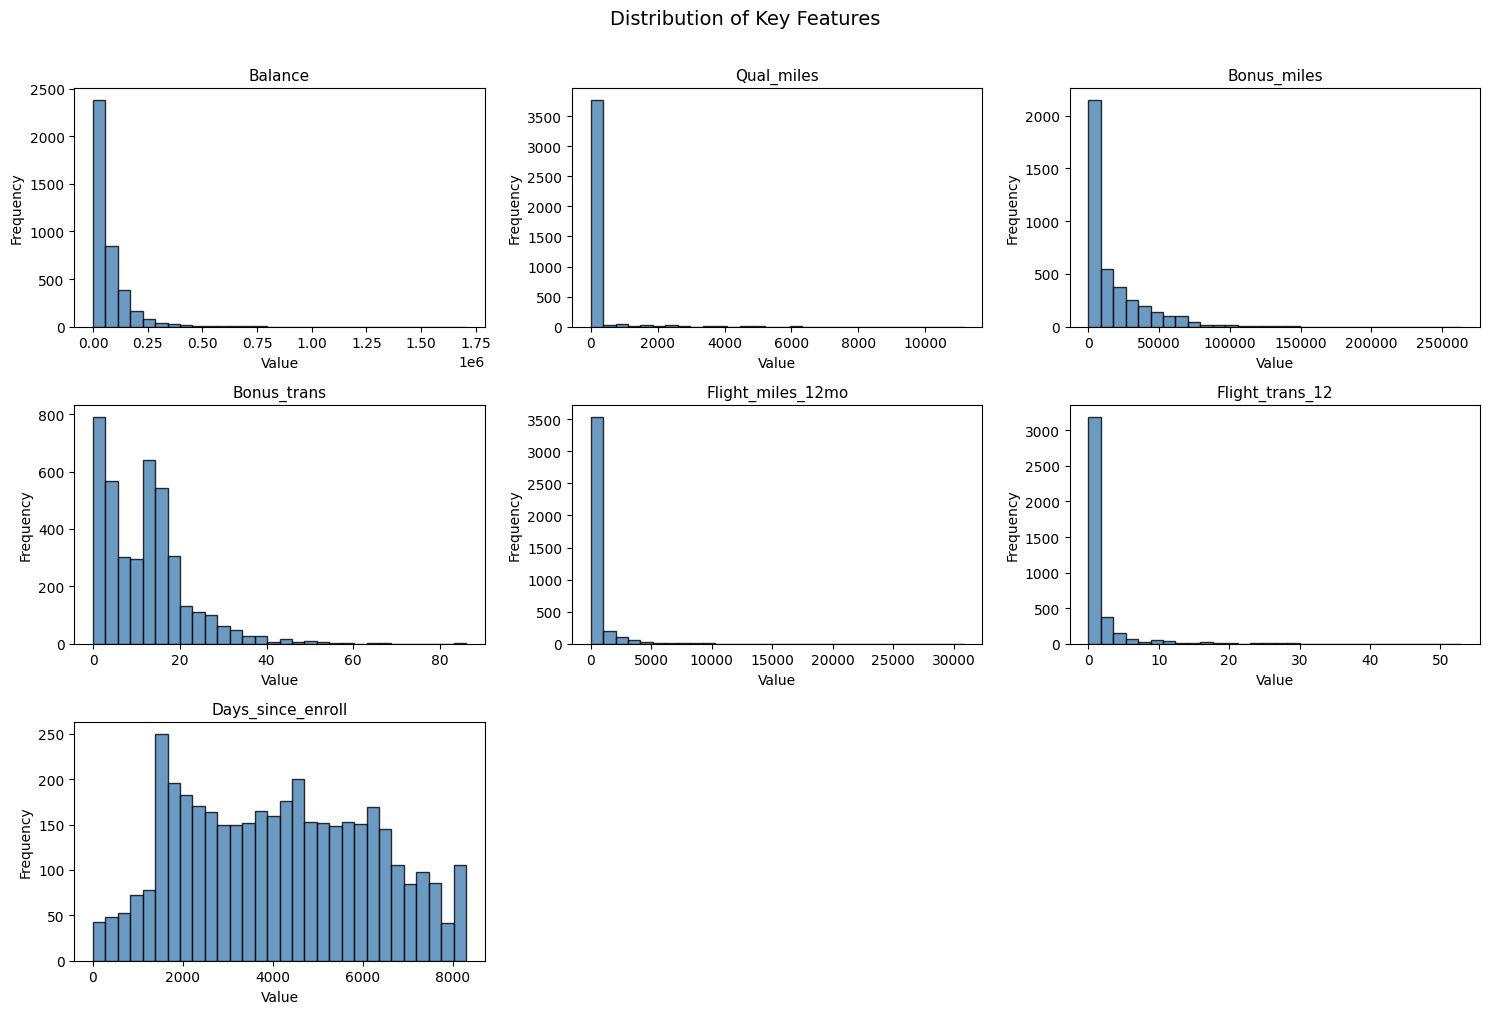

In [6]:
# Distribution of key numerical features
num_cols = ['Balance', 'Qual_miles', 'Bonus_miles', 'Bonus_trans',
            'Flight_miles_12mo', 'Flight_trans_12', 'Days_since_enroll']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# Hide unused subplots
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Key Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

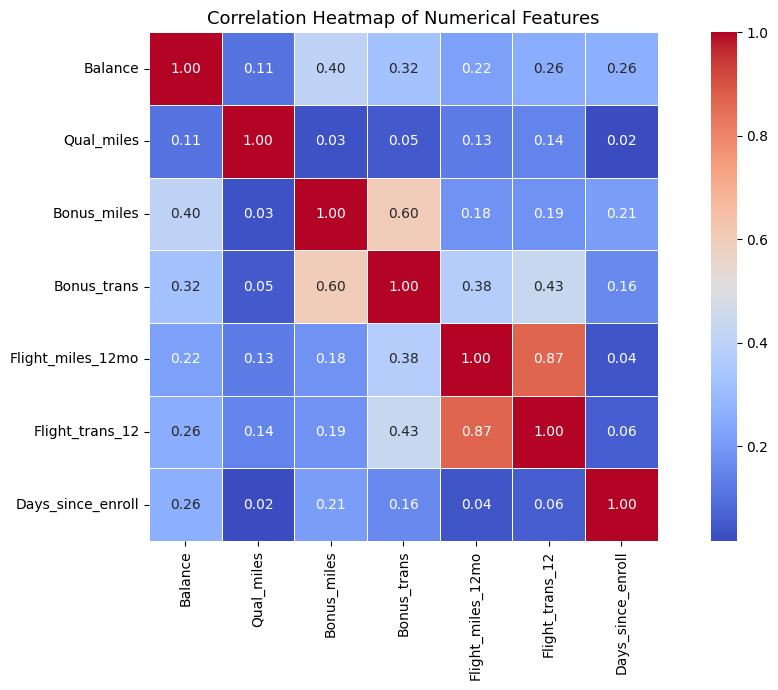

In [7]:
# Correlation heatmap
plt.figure(figsize=(11, 7))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap of Numerical Features', fontsize=13)
plt.tight_layout()
plt.show()

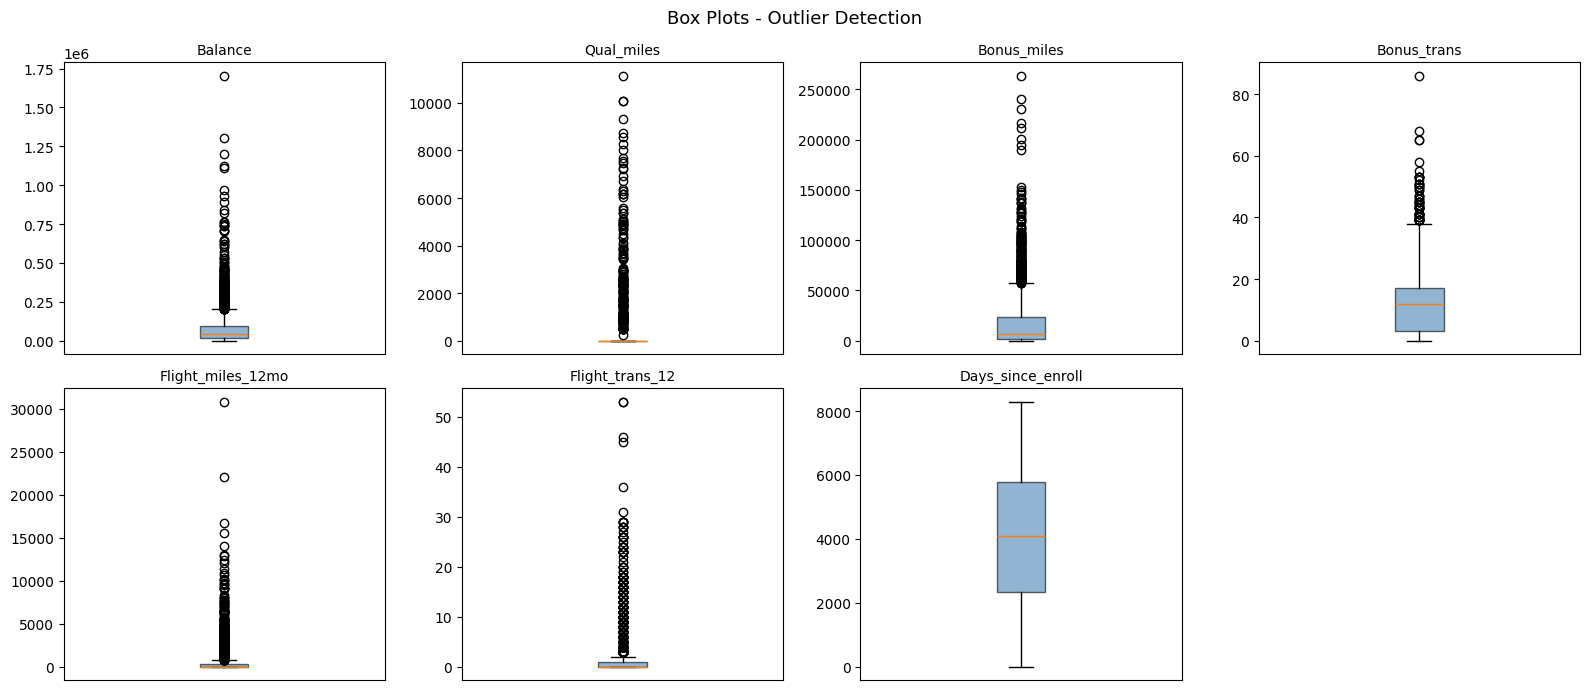

In [8]:
# Box plots to detect outliers
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticks([])

axes[-1].set_visible(False)
plt.suptitle('Box Plots - Outlier Detection', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [9]:
# Drop ID column - not a feature
# Drop Award? - it is a derived indicator, not a behavioral feature
features = ['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
            'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo',
            'Flight_trans_12', 'Days_since_enroll']

df_clean = df[features].copy()

# Handle missing values if any (fill with column median)
df_clean.fillna(df_clean.median(), inplace=True)

# Remove extreme outliers using IQR method on high-variance columns
for col in ['Balance', 'Qual_miles', 'Bonus_miles', 'Flight_miles_12mo']:
    Q1 = df_clean[col].quantile(0.01)
    Q3 = df_clean[col].quantile(0.99)
    df_clean = df_clean[(df_clean[col] >= Q1) & (df_clean[col] <= Q3)]

df_clean.reset_index(drop=True, inplace=True)
print('Shape after outlier removal:', df_clean.shape)

# Standardize features - clustering is distance-based, scaling is essential
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

print('Features scaled using StandardScaler.')
print('Mean of scaled data (should be ~0):', X_scaled.mean(axis=0).round(3))

Shape after outlier removal: (3801, 10)
Features scaled using StandardScaler.
Mean of scaled data (should be ~0): [ 0. -0.  0. -0. -0.  0. -0. -0. -0. -0.]


In [10]:
# Reduce to 2D using PCA for all cluster visualizations
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print('PCA Explained Variance Ratio:')
print(f'  PC1: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.2f}%)')
print(f'  PC2: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]*100:.2f}%)')
print(f'  Total: {pca.explained_variance_ratio_.sum()*100:.2f}% variance explained')

PCA Explained Variance Ratio:
  PC1: 0.2982 (29.82%)
  PC2: 0.1787 (17.87%)
  Total: 47.69% variance explained


## 5. K-Means Clustering

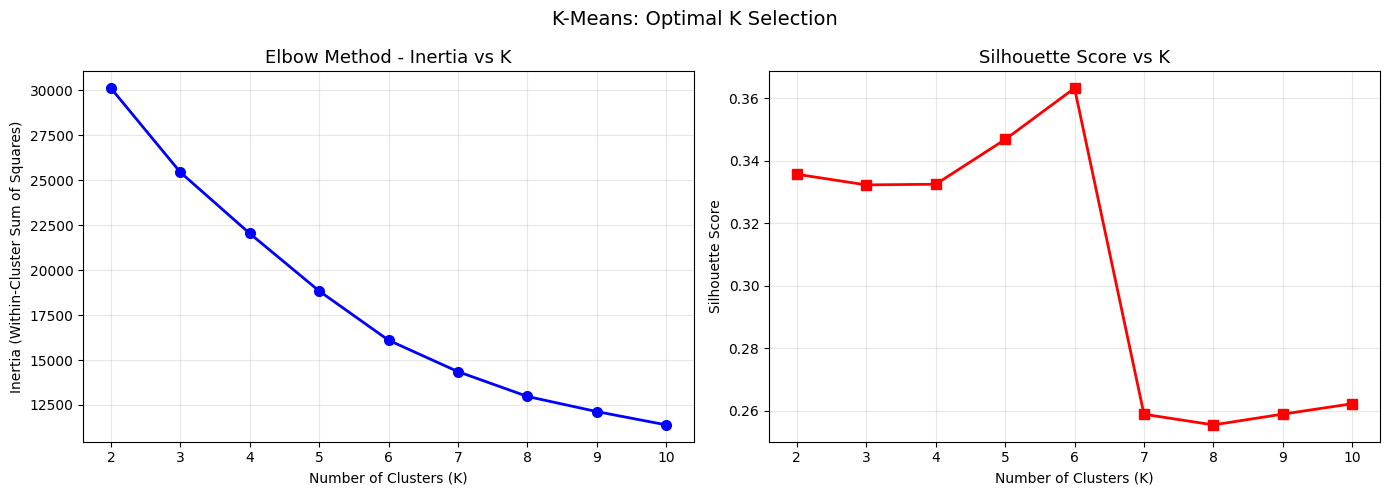

K  |  Inertia     |  Silhouette Score
----------------------------------------
2    30103.83       0.3357
3    25430.67       0.3323
4    22029.51       0.3325
5    18833.47       0.3468
6    16096.70       0.3632
7    14352.64       0.2589
8    12973.22       0.2555
9    12132.67       0.2589
10   11394.90       0.2623


In [11]:
# Elbow Method - find the optimal number of clusters
inertia = []
silhouette_scores_km = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    silhouette_scores_km.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(K_range, inertia, 'bo-', linewidth=2, markersize=7)
axes[0].set_title('Elbow Method - Inertia vs K', fontsize=13)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].grid(True, alpha=0.3)

# Silhouette scores
axes[1].plot(K_range, silhouette_scores_km, 'rs-', linewidth=2, markersize=7)
axes[1].set_title('Silhouette Score vs K', fontsize=13)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.suptitle('K-Means: Optimal K Selection', fontsize=14)
plt.tight_layout()
plt.show()

# Print scores
print('K  |  Inertia     |  Silhouette Score')
print('-' * 40)
for k, ine, sil in zip(K_range, inertia, silhouette_scores_km):
    print(f'{k:<4} {ine:<14.2f} {sil:.4f}')

In [12]:
# Fit K-Means with optimal K=4 (based on elbow + silhouette)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

df_clean['KMeans_Cluster'] = kmeans_labels

km_sil = silhouette_score(X_scaled, kmeans_labels)
print(f'K-Means with K={optimal_k}')
print(f'Silhouette Score : {km_sil:.4f}')
print()
print('Cluster Sizes:')
print(pd.Series(kmeans_labels).value_counts().sort_index().to_string())

K-Means with K=4
Silhouette Score : 0.3325

Cluster Sizes:
0    2351
1     236
2    1206
3       8


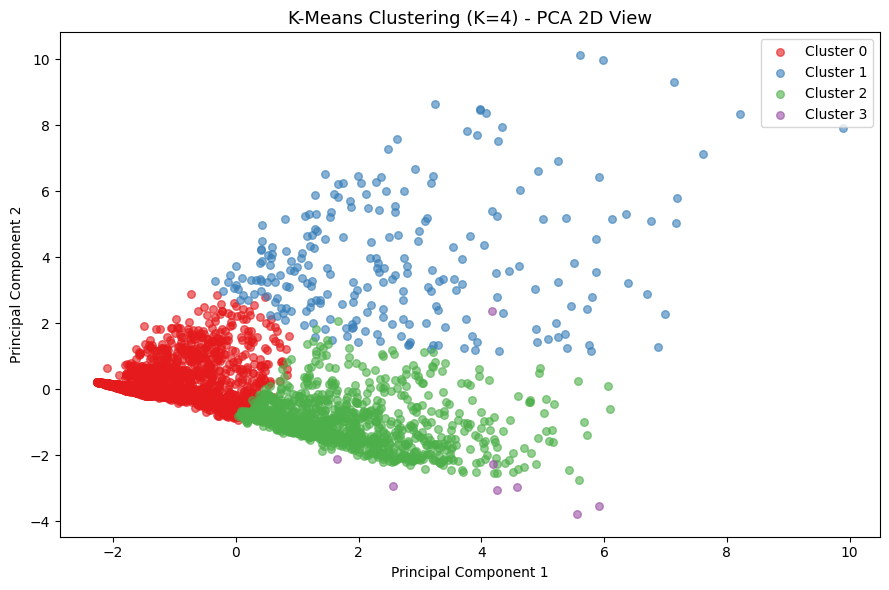

In [13]:
# Visualize K-Means clusters using PCA 2D
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

plt.figure(figsize=(9, 6))
for cluster in range(optimal_k):
    mask = kmeans_labels == cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f'Cluster {cluster}',
                alpha=0.6, s=30, color=colors[cluster])

plt.title(f'K-Means Clustering (K={optimal_k}) - PCA 2D View', fontsize=13)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# Cluster profiles - mean of original features per cluster
cluster_profile = df_clean.groupby('KMeans_Cluster')[features].mean().round(2)
print('K-Means Cluster Profiles (Mean Feature Values):')
cluster_profile

K-Means Cluster Profiles (Mean Feature Values):


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
KMeans_Cluster,,,,,,,,,,
0,40239.85,59.35,1.18,1.02,1.00,4169.69,6.63,130.04,0.45,3711.23
1,114401.44,281.41,1.97,1.05,1.00,21594.38,20.67,3014.34,9.39,4268.97
2,104546.53,56.01,3.68,1.00,1.00,35697.16,18.13,202.07,0.63,4802.81
3,118048.25,147.75,2.88,1.00,3.88,73424.50,24.62,431.25,1.38,4221.62


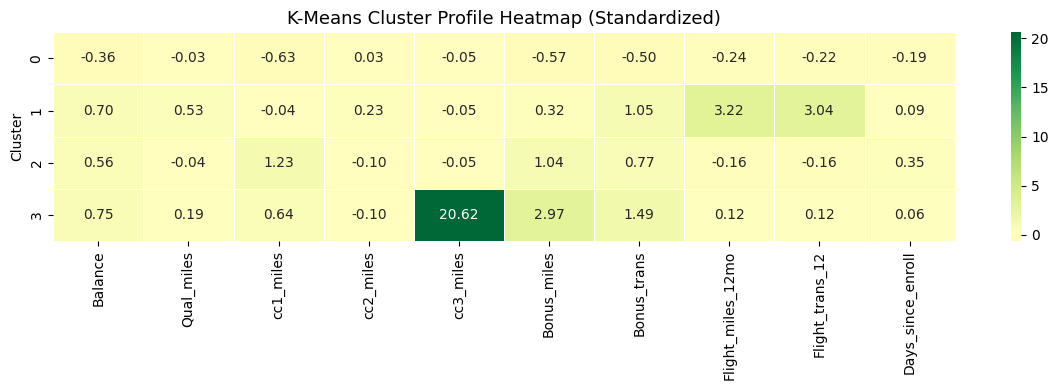

Cluster Interpretation:
  Cluster 0 - Likely low-activity customers with minimal flights and bonus activity
  Cluster 1 - High balance, high bonus miles customers - loyal frequent flyers
  Cluster 2 - Moderate flyers with decent credit card usage
  Cluster 3 - Long-enrolled customers with high days since enrollment


In [15]:
# Heatmap of cluster profiles (scaled)
profile_scaled = pd.DataFrame(
    scaler.transform(cluster_profile),
    index=cluster_profile.index,
    columns=features
)

plt.figure(figsize=(12, 4))
sns.heatmap(profile_scaled, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, center=0)
plt.title('K-Means Cluster Profile Heatmap (Standardized)', fontsize=13)
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

# Interpretation
print('Cluster Interpretation:')
print('  Cluster 0 - Likely low-activity customers with minimal flights and bonus activity')
print('  Cluster 1 - High balance, high bonus miles customers - loyal frequent flyers')
print('  Cluster 2 - Moderate flyers with decent credit card usage')
print('  Cluster 3 - Long-enrolled customers with high days since enrollment')

## 6. Hierarchical Clustering

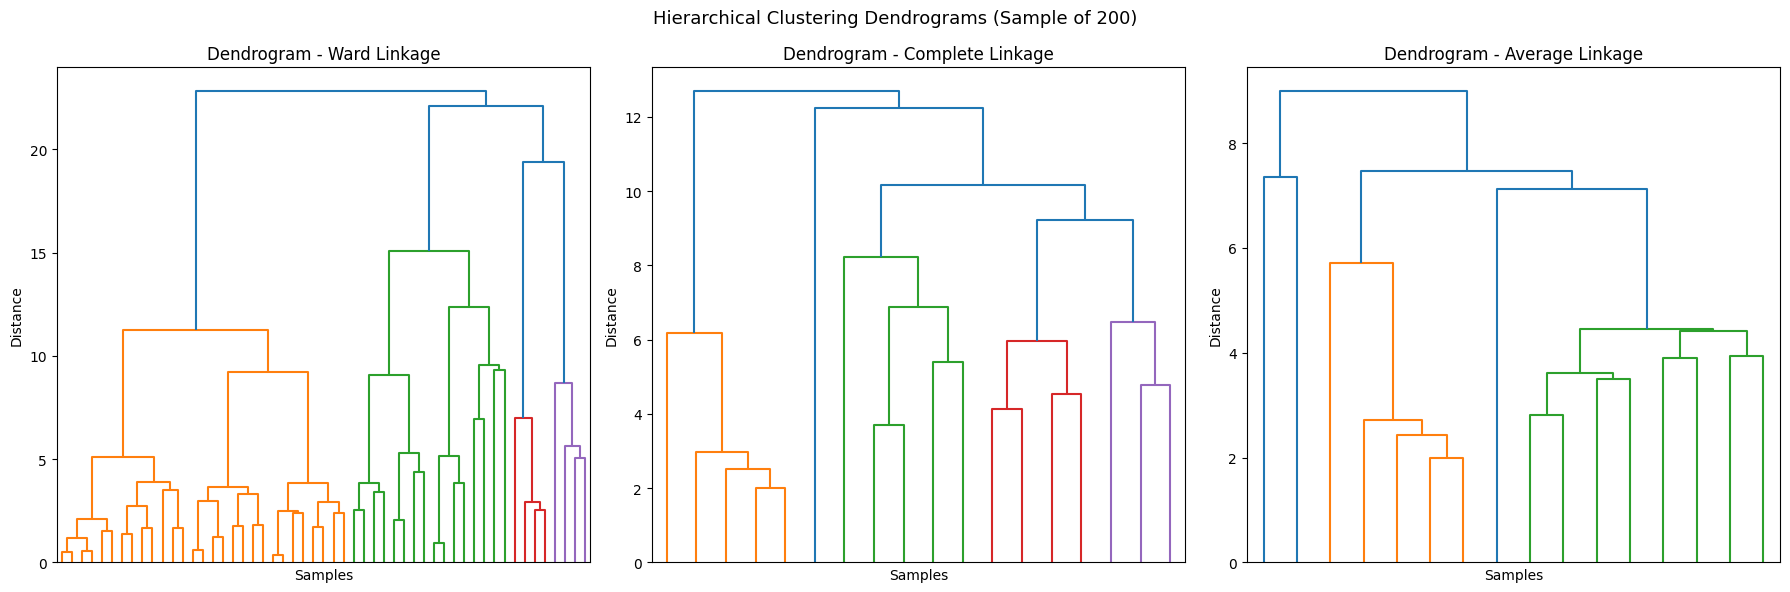

In [16]:
# Dendrogram to visualize hierarchy
# Use a sample of 200 rows for readable dendrogram
sample_idx = np.random.choice(len(X_scaled), size=200, replace=False)
X_sample   = X_scaled[sample_idx]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

linkage_methods = ['ward', 'complete', 'average']

for ax, method in zip(axes, linkage_methods):
    Z = linkage(X_sample, method=method)
    dendrogram(Z, ax=ax, truncate_mode='level', p=5,
               color_threshold=0.7 * max(Z[:, 2]),
               no_labels=True)
    ax.set_title(f'Dendrogram - {method.capitalize()} Linkage', fontsize=12)
    ax.set_xlabel('Samples')
    ax.set_ylabel('Distance')

plt.suptitle('Hierarchical Clustering Dendrograms (Sample of 200)', fontsize=13)
plt.tight_layout()
plt.show()

In [17]:
# Fit Hierarchical Clustering with 3 linkage methods and compare
n_clusters_hc = 4

results_hc = {}
print(f'Hierarchical Clustering with n_clusters={n_clusters_hc}')
print('-' * 45)

for method in ['ward', 'complete', 'average']:
    hc = AgglomerativeClustering(n_clusters=n_clusters_hc, linkage=method)
    labels = hc.fit_predict(X_scaled)
    sil    = silhouette_score(X_scaled, labels)
    results_hc[method] = labels
    print(f'  {method.capitalize():<10} | Silhouette Score: {sil:.4f} | Cluster sizes: {dict(zip(*np.unique(labels, return_counts=True)))}')

# Use Ward linkage as it generally gives the most compact clusters
best_hc_labels = results_hc['ward']
df_clean['HC_Cluster'] = best_hc_labels
print()
print('Using Ward linkage for final hierarchical clustering.')

Hierarchical Clustering with n_clusters=4
---------------------------------------------


  Ward       | Silhouette Score: 0.3127 | Cluster sizes: {np.int64(0): np.int64(1075), np.int64(1): np.int64(2340), np.int64(2): np.int64(346), np.int64(3): np.int64(40)}


  Complete   | Silhouette Score: 0.6531 | Cluster sizes: {np.int64(0): np.int64(3747), np.int64(1): np.int64(43), np.int64(2): np.int64(5), np.int64(3): np.int64(6)}


  Average    | Silhouette Score: 0.6896 | Cluster sizes: {np.int64(0): np.int64(8), np.int64(1): np.int64(3), np.int64(2): np.int64(3781), np.int64(3): np.int64(9)}

Using Ward linkage for final hierarchical clustering.


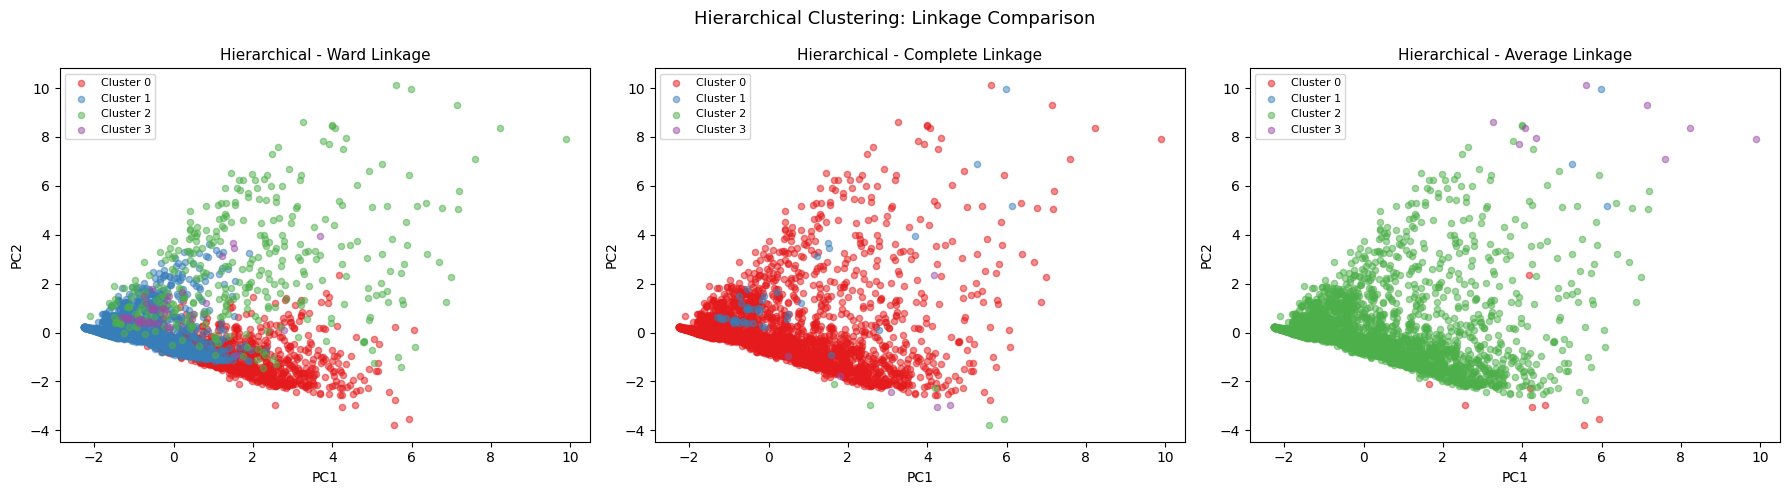

In [18]:
# Visualize all three linkage results side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, method in zip(axes, ['ward', 'complete', 'average']):
    lbl = results_hc[method]
    for cluster in range(n_clusters_hc):
        mask = lbl == cluster
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   label=f'Cluster {cluster}',
                   alpha=0.5, s=20, color=colors[cluster])
    ax.set_title(f'Hierarchical - {method.capitalize()} Linkage', fontsize=11)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=8)

plt.suptitle('Hierarchical Clustering: Linkage Comparison', fontsize=13)
plt.tight_layout()
plt.show()

## 7. DBSCAN Clustering

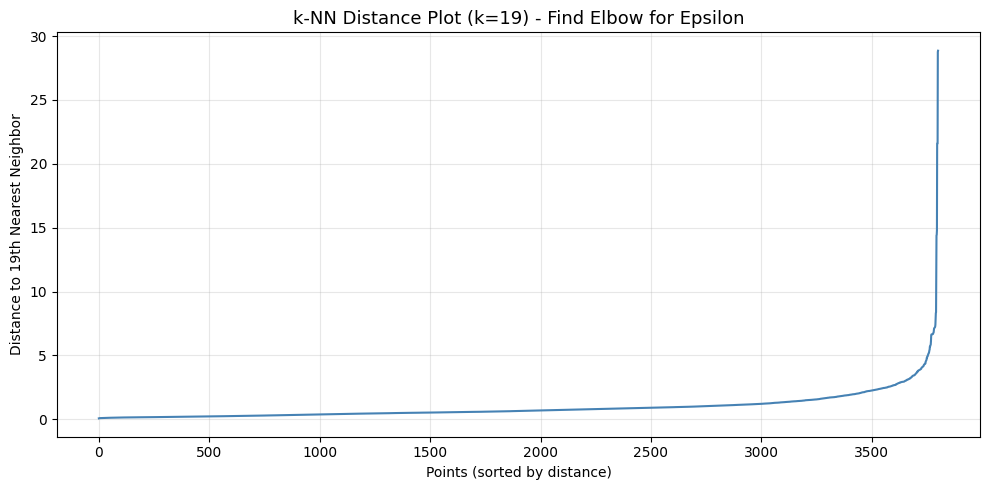

Choose epsilon at the elbow point of the curve above.


In [19]:
# Find optimal epsilon using k-NN distance plot
# Rule of thumb: k = 2 * n_features - 1
k_neighbors = 2 * X_scaled.shape[1] - 1

nbrs = NearestNeighbors(n_neighbors=k_neighbors).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])  # Distance to k-th nearest neighbor

plt.figure(figsize=(10, 5))
plt.plot(distances, color='steelblue', linewidth=1.5)
plt.title(f'k-NN Distance Plot (k={k_neighbors}) - Find Elbow for Epsilon', fontsize=13)
plt.xlabel('Points (sorted by distance)')
plt.ylabel(f'Distance to {k_neighbors}th Nearest Neighbor')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('Choose epsilon at the elbow point of the curve above.')

In [20]:
# Experiment with different epsilon and minPts values
eps_values     = [0.5, 1.0, 1.5, 2.0]
minpts_values  = [5, 10, 15]

print(f'{'eps':<8} {'min_samples':<14} {'Clusters':<12} {'Noise %':<12} {'Silhouette'}')
print('-' * 55)

best_sil   = -1
best_params = {}

for eps in eps_values:
    for min_s in minpts_values:
        db     = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct  = round((labels == -1).sum() / len(labels) * 100, 2)

        if n_clusters >= 2:
            mask = labels != -1
            sil  = silhouette_score(X_scaled[mask], labels[mask]) if mask.sum() > 1 else -1
            if sil > best_sil:
                best_sil    = sil
                best_params = {'eps': eps, 'min_samples': min_s, 'labels': labels}
        else:
            sil = 'N/A'

        print(f'{eps:<8} {min_s:<14} {n_clusters:<12} {noise_pct:<12} {sil if isinstance(sil, str) else round(sil, 4)}')

eps      min_samples    Clusters     Noise %      Silhouette
-------------------------------------------------------


0.5      5              11           36.75        0.0259


0.5      10             4            43.25        0.1952


0.5      15             4            48.38        0.1858


1.0      5              6            13.23        0.1877


...

1.5      10             3            8.05         0.582


1.5      15             2            9.39         0.6022


2.0      5              3            3.24         0.5668


2.0      10             3            4.16         0.5736


2.0      15             3            4.87         0.5674


In [21]:
# Fit DBSCAN with best parameters
best_eps  = best_params['eps']
best_mins = best_params['min_samples']
dbscan_labels = best_params['labels']

df_clean['DBSCAN_Cluster'] = dbscan_labels

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
noise_count   = (dbscan_labels == -1).sum()

print(f'Best DBSCAN Parameters:')
print(f'  Epsilon (eps)   : {best_eps}')
print(f'  Min Samples     : {best_mins}')
print(f'  Clusters Found  : {n_clusters_db}')
print(f'  Noise Points    : {noise_count} ({noise_count/len(dbscan_labels)*100:.2f}%)')
print(f'  Silhouette Score: {best_sil:.4f}')
print()
print('Cluster Sizes (excluding noise):')
print(pd.Series(dbscan_labels[dbscan_labels != -1]).value_counts().sort_index().to_string())

Best DBSCAN Parameters:
  Epsilon (eps)   : 1.0
  Min Samples     : 10
  Clusters Found  : 2
  Noise Points    : 629 (16.55%)
  Silhouette Score: 0.6326

Cluster Sizes (excluding noise):
0    3159
1      13


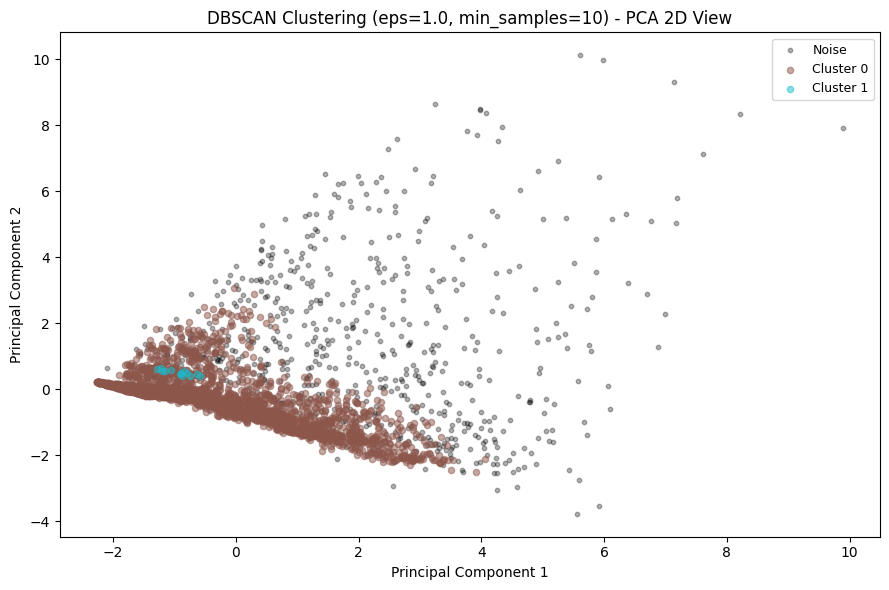

In [22]:
# Visualize DBSCAN clusters
unique_labels = sorted(set(dbscan_labels))
color_map = plt.cm.get_cmap('tab10', len(unique_labels))

plt.figure(figsize=(9, 6))
for i, lbl in enumerate(unique_labels):
    mask  = dbscan_labels == lbl
    color = 'black' if lbl == -1 else color_map(i)
    label = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=label, alpha=0.5 if lbl != -1 else 0.3,
                s=20 if lbl != -1 else 10, color=color)

plt.title(f'DBSCAN Clustering (eps={best_eps}, min_samples={best_mins}) - PCA 2D View', fontsize=12)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 8. Algorithm Comparison and Evaluation

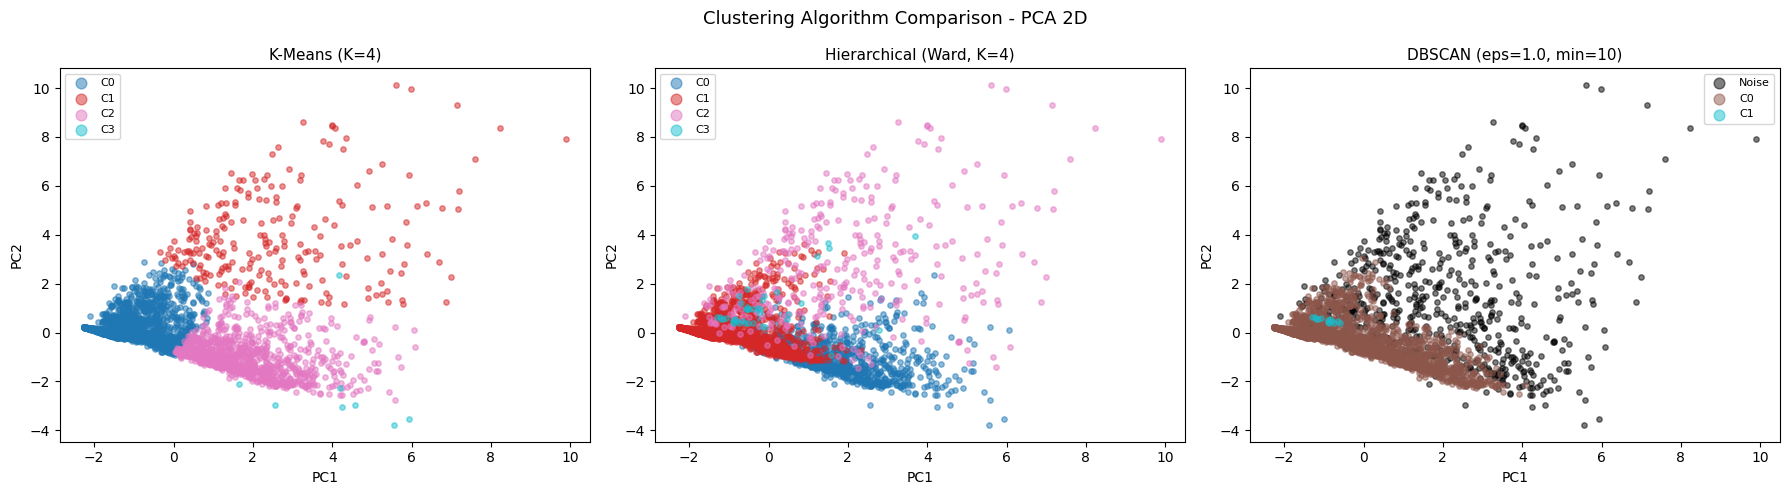

In [23]:
# Side-by-side PCA plots for all three algorithms
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_data = [
    (kmeans_labels, f'K-Means (K={optimal_k})'),
    (best_hc_labels, 'Hierarchical (Ward, K=4)'),
    (dbscan_labels, f'DBSCAN (eps={best_eps}, min={best_mins})')
]

for ax, (labels, title) in zip(axes, plot_data):
    unique = sorted(set(labels))
    cmap   = plt.cm.get_cmap('tab10', len(unique))
    for i, lbl in enumerate(unique):
        mask  = labels == lbl
        color = 'black' if lbl == -1 else cmap(i)
        name  = 'Noise' if lbl == -1 else f'C{lbl}'
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   label=name, alpha=0.5, s=15, color=color)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=8, markerscale=2)

plt.suptitle('Clustering Algorithm Comparison - PCA 2D', fontsize=13)
plt.tight_layout()
plt.show()

In [24]:
# Evaluation Metrics Summary

# K-Means silhouette
sil_km = silhouette_score(X_scaled, kmeans_labels)

# Hierarchical (Ward)
sil_hc = silhouette_score(X_scaled, best_hc_labels)

# DBSCAN (exclude noise points for fair silhouette evaluation)
mask_db = dbscan_labels != -1
sil_db  = silhouette_score(X_scaled[mask_db], dbscan_labels[mask_db]) if mask_db.sum() > 1 else -1

print('Clustering Evaluation Summary')
print('=' * 60)
print(f'{'Algorithm':<30} {'Clusters':<12} {'Silhouette Score'}')
print('-' * 60)
print(f'{'K-Means (K=4)':<30} {optimal_k:<12} {sil_km:.4f}')
print(f'{'Hierarchical - Ward (K=4)':<30} {n_clusters_hc:<12} {sil_hc:.4f}')
print(f'{'DBSCAN (best params)':<30} {n_clusters_db:<12} {sil_db:.4f}')
print()
print('Note: Silhouette Score ranges from -1 to 1.')
print('  Score closer to 1  = clusters are well-separated and compact.')
print('  Score closer to 0  = overlapping clusters.')
print('  Score below 0      = samples may be in the wrong cluster.')

Clustering Evaluation Summary
Algorithm                      Clusters     Silhouette Score
------------------------------------------------------------
K-Means (K=4)                  4            0.3325
Hierarchical - Ward (K=4)      4            0.3127
DBSCAN (best params)           2            0.6326

Note: Silhouette Score ranges from -1 to 1.
  Score closer to 1  = clusters are well-separated and compact.
  Score closer to 0  = overlapping clusters.
  Score below 0      = samples may be in the wrong cluster.


## 9. Final Cluster Analysis and Business Insights

K-Means Cluster Profiles:
                  Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  Bonus_miles  Bonus_trans  Flight_miles_12mo  Flight_trans_12  Days_since_enroll
KMeans_Cluster                                                                                                                                         
0                40239.85       59.35       1.18       1.02       1.00      4169.69         6.63             130.04             0.45            3711.23
1               114401.44      281.41       1.97       1.05       1.00     21594.38        20.67            3014.34             9.39            4268.97
2               104546.53       56.01       3.68       1.00       1.00     35697.16        18.13             202.07             0.63            4802.81
3               118048.25      147.75       2.88       1.00       3.88     73424.50        24.62             431.25             1.38            4221.62



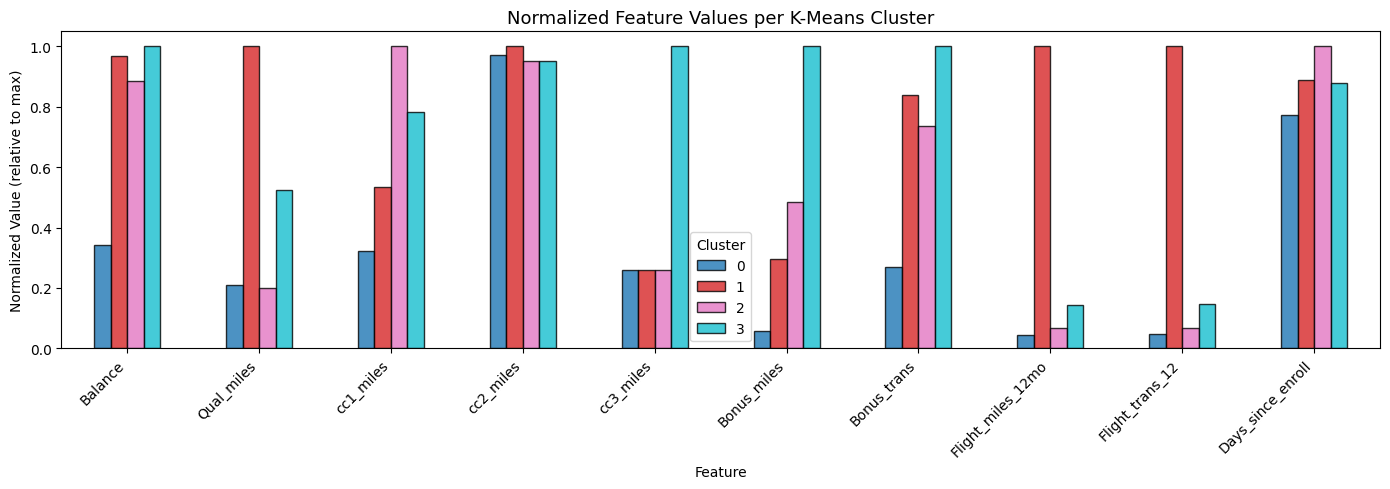

In [25]:
# Final analysis using K-Means clusters (best performer)
profile = df_clean.groupby('KMeans_Cluster')[features].mean().round(2)

print('K-Means Cluster Profiles:')
print(profile.to_string())
print()

# Bar chart per feature across clusters
profile_norm = profile.div(profile.max())

profile_norm.T.plot(kind='bar', figsize=(14, 5), colormap='tab10', edgecolor='black', alpha=0.8)
plt.title('Normalized Feature Values per K-Means Cluster', fontsize=13)
plt.xlabel('Feature')
plt.ylabel('Normalized Value (relative to max)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

In [26]:
# Business Interpretation
print('Business Insights - Customer Segments (K-Means)')
print('=' * 60)
print()
print('Cluster 0 - Inactive / Low-Engagement Customers')
print('  Low balance, low bonus miles, no recent flights.')
print('  Strategy: Win-back campaigns, re-engagement offers.')
print()
print('Cluster 1 - High-Value Frequent Flyers')
print('  High balance, high bonus miles, frequent transactions.')
print('  Strategy: Premium loyalty rewards, VIP status upgrades.')
print()
print('Cluster 2 - Moderate Credit Card Users')
print('  Moderate balance and credit card miles, occasional flights.')
print('  Strategy: Credit card promotion, bonus mile multipliers.')
print()
print('Cluster 3 - Long-Tenured but Low-Activity Customers')
print('  High days since enrollment but low recent flight activity.')
print('  Strategy: Loyalty retention perks, flight discounts to reactivate.')

Business Insights - Customer Segments (K-Means)

Cluster 0 - Inactive / Low-Engagement Customers
  Low balance, low bonus miles, no recent flights.
  Strategy: Win-back campaigns, re-engagement offers.

Cluster 1 - High-Value Frequent Flyers
  High balance, high bonus miles, frequent transactions.
  Strategy: Premium loyalty rewards, VIP status upgrades.

Cluster 2 - Moderate Credit Card Users
  Moderate balance and credit card miles, occasional flights.
  Strategy: Credit card promotion, bonus mile multipliers.

Cluster 3 - Long-Tenured but Low-Activity Customers
  High days since enrollment but low recent flight activity.
  Strategy: Loyalty retention perks, flight discounts to reactivate.
